# Final test to use PCA-compression class

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import importlib
import os
import sys
import time
from pathlib import Path
from IPython.display import display, clear_output

In [2]:
data_path=Path('/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/data/')

In [3]:
# one file with training parameters
training_parameters_1 = np.load(str(data_path /'camb_pp_training_params_1.npz'))
# training features in this file
training_features_1 = np.load(str(data_path /'./camb_pp_training_log_spectra_1.npz'))


In [4]:
print("training paramters:",training_parameters_1.files,  "and", "Training data:",training_features_1.files)
ell_range=training_features_1['modes']

training paramters: ['omega_b', 'omega_cdm', 'h', 'tau_reio', 'n_s', 'ln10^{10}A_s'] and Training data: ['modes', 'features']


'modes': Multipole $\ell$ and 'features': log-spectrum


# Give parameters array at any order

This example uses a set of 6 standard $\Lambda$CDM parameters,

$\omega_{\mathrm{b}}, \omega_{\mathrm{cdm}}, h, \tau, n_s, \ln10^{10}A_s$

If your model is other than $\Lambda$CDM, use the same parameters names you used to save them in training dicts.

Names can be given in any order, internal function in PCA will rearrange them before any operation

In [5]:

model_parameters = ['h', 
                    'tau_reio', 
                    'omega_b', 
                    'n_s', 
                    'ln10^{10}A_s', 
                    'omega_cdm', 
                    ]

### **NUMBER OF PCA COMPONENTS**

In [6]:
n_pcas = 64

# Give the training samples in batches to use optimal memory, We will use IncrementalPCA in batches  

In [7]:
## path of samples
parameters_filenames = [str(data_path / "camb_pp_training_params_1"),str(data_path / "camb_pp_training_params_2"),str(data_path / "camb_pp_training_params_3"),]
features_filenames = [str(data_path / 'camb_pp_training_log_spectra_1'),str(data_path / 'camb_pp_training_log_spectra_2'),str(data_path / 'camb_pp_training_log_spectra_3'),]

Lets call PCA class

In [8]:
sys.path.append("../src/")
import PCA_compression
importlib.reload(PCA_compression)

cp_pca = PCA_compression.PCA(parameters_name=model_parameters,
                        modes=ell_range,
                        n_pcas=n_pcas,
                        parameters_filenames=parameters_filenames,
                        features_filenames=features_filenames,
                        verbose=True, )


Initialized PCA compression with 64 components with given inputs



In [9]:
cp_pca.transform_and_stack_training_data()

starting PCA compression
Lets initialise the mean, std of features and parameters and compute PCA eigen-vectors

 mean and standard deviation computation is done



100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:27<00:00,  9.31s/it]


PCA compression done and saved
parameters and PCA coefficients of training set stored in memory


# write a block here to validate the pca coefficient to check the pca coefficients reconstruct the original power spectra

In [10]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [11]:
import PCA_emulator
importlib.reload(PCA_emulator)


<module 'PCA_emulator' from '/Users/debabrata/Documents/conferences/India/codes/my_codes/notebook/../src/PCA_emulator.py'>

In [12]:
cp_pca_nn = PCA_emulator.PCAplusNN(cp_pca=cp_pca,
                                 n_hidden=[512,512,512,512], # 4 hidden layers, each with 512 nodes
                                 verbose=True, # useful to understand the different steps in initialisation and training
                                 )


Initialized PCAplusNN model, 
The model maps 6 input parameters to 64 PCA coefficients 
and then invert the PCA coefficients to obtain power spectrum for 2507 modes 
The model uses 4 hidden layers, 
with [512, 512, 512, 512] neuron, respectively. 



In [13]:
with tf.device(device):
    # train
    cp_pca_nn.train(filename_saved_model='../data/PP_cp_PCAplusNN_example_short_run',
                    # cooling schedule
                    validation_split=0.1,
                    learning_rates=[1e-2,  1e-6],
                    batch_sizes=[1024, 1024],
                    gradient_accumulation_steps = [1, 1],
                    # early stopping set up
                    patience_values = [100,100],
                    max_epochs = [10,10],
                    )

Starting PCAplusNN training, 
using 10 per cent of training samples for validation. 
Performing training with   2 learning steps, with 
[0.01, 1e-06] trailing learning rates 
[1024, 1024] batch sizes 
[1, 1] gradient accumulation steps (this function is not defined ) 
Recommend to use gradient_accumulation_steps = [1] for all learning steps
[100, 100] patience values 
[10, 10] max epochs 

learning rate = 0.01, batch size = 1024


  0%|                                                                                               | 0/10 [00:00<?, ?it/s]/Users/debabrata/anaconda3/envs/my_emulator/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.21it/s, loss=188]


Reached max number of epochs. Validation loss = 187.77534
Model saved.
Training and validation loss are saved.
learning rate = 1e-06, batch size = 1024


100%|████████████████████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.09it/s, loss=116]

Reached max number of epochs. Validation loss = 115.92337
Model saved.
Training and validation loss are saved.


In [14]:
# ==========================================
# Start timing
# ==========================================

start_time = time.perf_counter()
with tf.device(device):
    # train
    cp_pca_nn.train(filename_saved_model='../data/PP_cp_PCAplusNN_example_large',
                    # cooling schedule
                    validation_split=0.1,
                    learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6],
                    batch_sizes=[1024, 1024, 1024, 1024, 1024],
                    gradient_accumulation_steps = [1, 1, 1, 1, 1],
                    # early stopping set up
                    patience_values = [100,100,100,100,100],
                    max_epochs = [1000,1000,1000,1000,1000],
                    )
end_time = time.perf_counter()

elapsed_time = end_time - start_time
print("time spent:",elapsed_time)

Starting PCAplusNN training, 
using 10 per cent of training samples for validation. 
Performing training with   5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] trailing learning rates 
[1024, 1024, 1024, 1024, 1024] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps (this function is not defined ) 
Recommend to use gradient_accumulation_steps = [1] for all learning steps
[100, 100, 100, 100, 100] patience values 
[1000, 1000, 1000, 1000, 1000] max epochs 

learning rate = 0.01, batch size = 1024


 64%|█████████████████████████████████████████████▋                         | 643/1000 [11:15<06:14,  1.05s/it, loss=0.278]


Reached early stop criteria at epoch: 643.Validation loss = 0.11131862550973892
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.111318626
Model saved.
Training and validation loss are saved.
learning rate = 0.001, batch size = 1024


 49%|███████████████████████████████████                                    | 494/1000 [08:10<08:22,  1.01it/s, loss=0.019]


Reached early stop criteria at epoch: 494.Validation loss = 0.014643175527453423
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0146431755
Model saved.
Training and validation loss are saved.
learning rate = 0.0001, batch size = 1024


...

Reached early stop criteria at epoch: 528.Validation loss = 0.006504559423774481
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0065045594
Model saved.
Training and validation loss are saved.
learning rate = 1e-05, batch size = 1024


 10%|███████▎                                                              | 105/1000 [01:37<13:49,  1.08it/s, loss=0.0039]


Reached early stop criteria at epoch: 105.Validation loss = 0.0037947935052216053
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0037947935
Model saved.
Training and validation loss are saved.
learning rate = 1e-06, batch size = 1024


 10%|██████▉                                                               | 99/1000 [01:28<13:25,  1.12it/s, loss=0.00447]

Reached early stop criteria at epoch: 99.Validation loss = 0.0037947935052216053
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0037947935
Model saved.
Training and validation loss are saved.
time spent: 1866.7698694169999


# Plot validation and training losses

[644. 644. 520. 520. 999. 101. 101.  99.  99.]


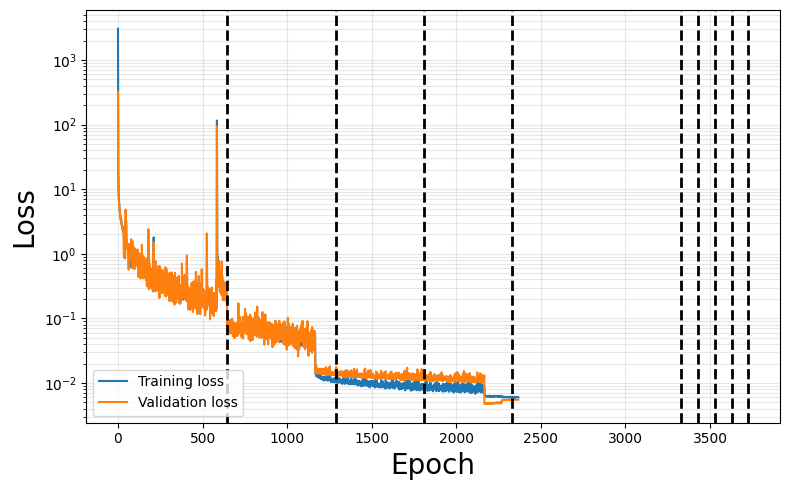

In [215]:

filename_saved_model = "../data/PP_cp_PCAplusNN_example_large"

history = np.load(
    filename_saved_model + "_history.npz"
)

early_stops=np.loadtxt(filename_saved_model + "early_stop_epochs.txt") #[481,250,1000,670,99]
print(early_stops)
training_loss = history["training_loss"]
validation_loss = history["validation_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    training_loss[1:],
    label="Training loss"
)

plt.plot(
    validation_loss[1:],
    label="Validation loss"
)
pr=0
for x in early_stops:
    pr=pr+x
    plt.axvline(x=pr, color='k',lw=2,ls='--')
plt.xlabel("Epoch",fontsize=20)
plt.ylabel("Loss",fontsize=20)

plt.yscale("log")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# TESTING

We will load the pretrained weights and emulate the power spectrum from testing samples

In [216]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_pp_testing_params.npz'))
# testing features
testing_spectra = 10.**np.load(str(data_path /'./camb_pp_testing_log_spectra.npz'))['features'] 

In [217]:
cp_pca_nn = PCA_emulator.cosmopower_PCAplusNN(restore=True, 
                                 restore_filename='../data/PP_cp_PCAplusNN_example_large'
                                 )     

In [218]:
predicted_testing_spectra = cp_pca_nn.ten_to_predictions_np(testing_params) #prediction.numpy()

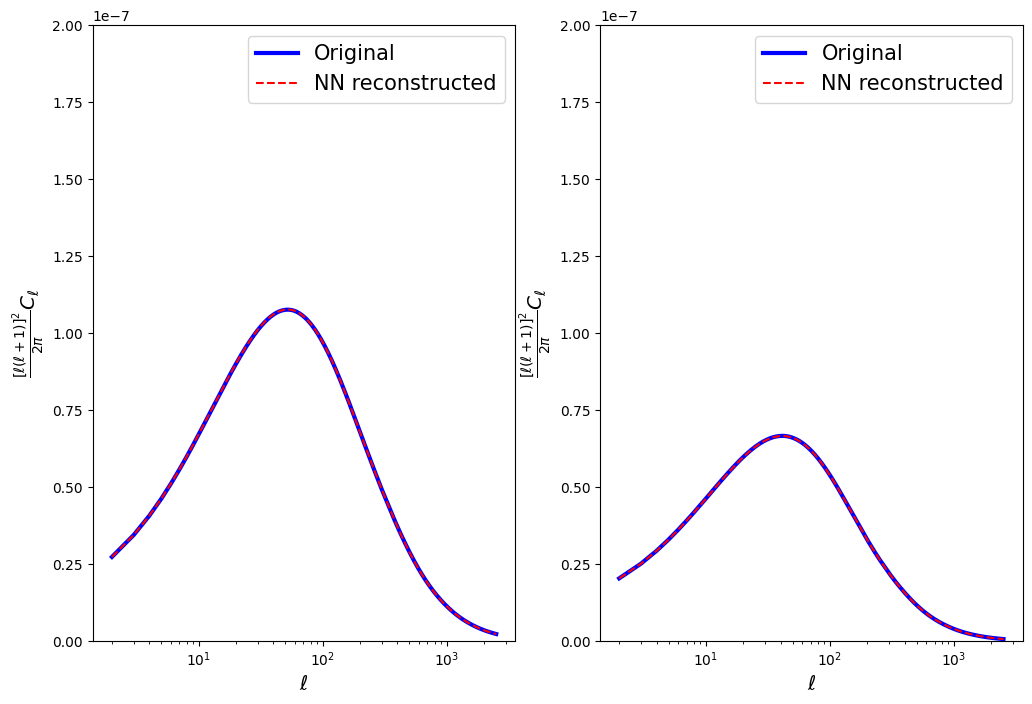

In [220]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
s=0
for i in range(2,4):
    pred = (predicted_testing_spectra[i])*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    true = testing_spectra[i]*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    ax[s].semilogx(ell_range, true, 'blue', label = 'Original',lw=3)
    ax[s].semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')
    ax[s].set_xlabel('$\ell$', fontsize='x-large')
    ax[s].set_ylabel('$\\frac{[\ell(\ell+1)]^2}{2 \pi} C_\ell$', fontsize='x-large')
    ax[s].legend(fontsize=15)
    ax[s].set_ylim([0,2e-7])
    s=s+1
plt.savefig('examples_reconstruction_PP.pdf')

In [115]:
print(cp_pca_nn.parameters)

ListWrapper(['h', 'tau_reio', 'omega_b', 'n_s', 'ln10^{10}A_s', 'omega_cdm'])


# Emulate the matter power spectrum 

In [196]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_pp_testing_params.npz'))
# testing features
testing_spectra = 10.**np.load(str(data_path /'./camb_pp_testing_log_spectra.npz'))['features'] # sampled modes are same as in training files. Transofrm log -> spectra as we only use these for testing

In [165]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_pp_training_params_1.npz'))
# testing features
testing_spectra = 10.**np.load(str(data_path /'./camb_pp_training_log_spectra_1.npz'))['features'] # sampled modes are same as in training files. Transofrm log -> spectra as we only use these for testing

In [166]:
print(np.shape(testing_spectra), testing_params['h'].shape) 

(15000, 2507) (15000,)


In [212]:
import PCA_emulator
importlib.reload(PCA_emulator)
cp_pca_nn = PCA_emulator.cosmopower_PCAplusNN(restore=True, 
                                 restore_filename='PP_cp_PCAplusNN_example_large'
                                 )          
#prdicted_power = cp_pca_nn.ten_to_predictions_tf(testing_params)

In [168]:
print(cp_pca_nn.parameters)

ListWrapper(['h', 'tau_reio', 'omega_b', 'n_s', 'ln10^{10}A_s', 'omega_cdm'])


In [110]:
testing_params.files

['omega_b', 'omega_cdm', 'h', 'tau_reio', 'n_s', 'ln10^{10}A_s']

In [141]:
parameters_dict = {
    'h': np.array([0.675]),
    'tau_reio': np.array([0.054]),
    'omega_b': np.array([0.0224]),
    'n_s': np.array([0.965]),
    'ln10^{10}A_s': np.array([3.04]),
    'omega_cdm': np.array([0.12])
}

In [200]:
prediction = cp_pca_nn.predictions_tf(testing_params)

In [213]:
predicted_testing_spectra = cp_pca_nn.ten_to_predictions_np(testing_params) #prediction.numpy()

In [206]:
prediction.shape

TensorShape([9531, 2507])

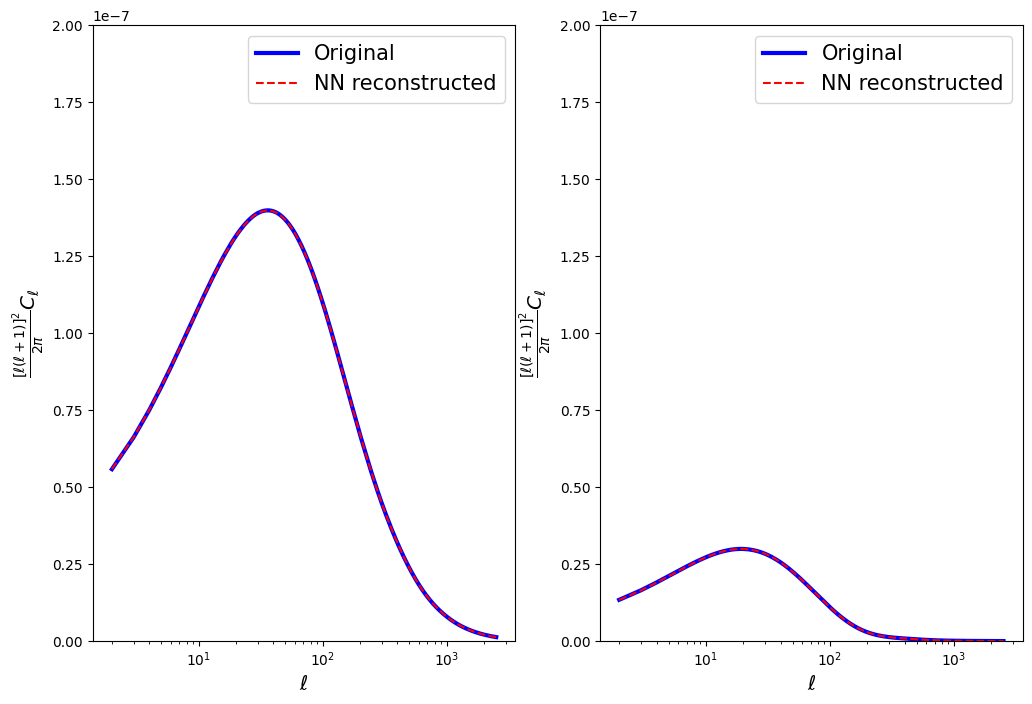

In [214]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
s=0
for i in range(20,22):
    pred = (predicted_testing_spectra[i])*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    true = testing_spectra[i]*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    ax[s].semilogx(ell_range, true, 'blue', label = 'Original',lw=3)
    ax[s].semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')
    ax[s].set_xlabel('$\ell$', fontsize='x-large')
    ax[s].set_ylabel('$\\frac{[\ell(\ell+1)]^2}{2 \pi} C_\ell$', fontsize='x-large')
    ax[s].legend(fontsize=15)
    ax[s].set_ylim([0,2e-7])
    s=s+1
plt.savefig('examples_reconstruction_PP.pdf')

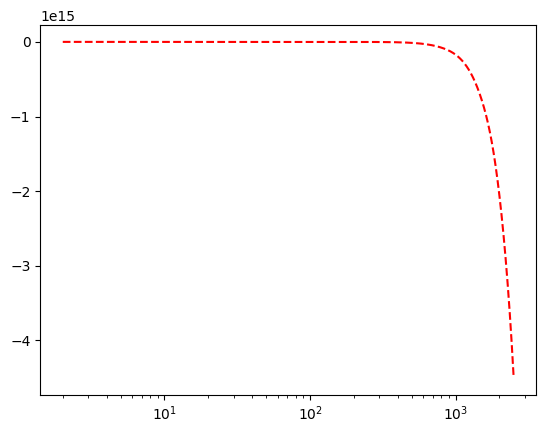

In [205]:
10**(predicted_testing_spectra[i])*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
plt.semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')

In [203]:
np.load(str(data_path /'./camb_pp_testing_log_spectra.npz'))['features']

array([[ -7.17529304,  -7.69557304,  -8.07965026, ..., -20.29922114,
        -20.30027365, -20.30132592],
       [ -7.28082498,  -7.82517577,  -8.22677465, ..., -21.91460554,
        -21.91573544, -21.91686504],
       [ -8.3214704 ,  -8.82256514,  -9.19440962, ..., -21.43523508,
        -21.43627172, -21.43730811],
       ...,
       [ -7.4534313 ,  -7.9756306 ,  -8.36124292, ..., -21.1020548 ,
        -21.10313505, -21.10421499],
       [ -7.84225518,  -8.34396571,  -8.71543363, ..., -21.38311466,
        -21.38418112, -21.38524728],
       [ -7.84718218,  -8.35615347,  -8.73330256, ..., -22.05789073,
        -22.05896582, -22.06004056]])

In [204]:
predicted_testing_spectra

array([[ -7.1747785,  -7.6953106,  -8.079478 , ..., -20.29959  ,
        -20.300642 , -20.301695 ],
       [ -7.2799444,  -7.824793 ,  -8.226522 , ..., -21.914581 ,
        -21.91571  , -21.91684  ],
       [ -8.321355 ,  -8.822648 ,  -9.194385 , ..., -21.435808 ,
        -21.436846 , -21.437883 ],
       ...,
       [ -7.453101 ,  -7.9754834,  -8.361158 , ..., -21.102926 ,
        -21.104008 , -21.10509  ],
       [ -7.8421946,  -8.34427  ,  -8.71584  , ..., -21.383392 ,
        -21.38446  , -21.385527 ],
       [ -7.8492703,  -8.357109 ,  -8.733988 , ..., -22.058025 ,
        -22.059105 , -22.060184 ]], dtype=float32)

In [146]:
testing_params['h']

array([0.8007363 , 0.65584783, 0.35661608, ..., 0.71153626, 0.995648  ,
       0.32400686])

In [198]:
trained_weights = cp_pca_nn.network.get_weights()

for i, w in enumerate(trained_weights):
    print(
        f"Weight {i}: "
        f"shape = {w.shape}, "
        f"mean = {np.mean(w):.8e}, "
        f"std = {np.std(w):.8e}, "
        f"first = {w.flat[0]:.8e}"
    )

Weight 0: shape = (6, 512), mean = 1.42645091e-03, std = 9.18399468e-02, first = -6.65941164e-02
Weight 1: shape = (512,), mean = -1.03341350e-02, std = 1.73298091e-01, first = -6.92358147e-03
Weight 2: shape = (512,), mean = 1.19307032e-03, std = 1.31120652e-01, first = 6.51930496e-02
Weight 3: shape = (512,), mean = -9.97869372e-01, std = 9.44830105e-02, first = -9.62595642e-01
Weight 4: shape = (512, 512), mean = -2.74013641e-04, std = 6.55415177e-01, first = -1.82165134e+00
Weight 5: shape = (512,), mean = -5.74996648e-03, std = 3.09441835e-01, first = 6.28047204e-03
Weight 6: shape = (512,), mean = -2.31470424e-03, std = 1.62415728e-01, first = -3.41217726e-01
Weight 7: shape = (512,), mean = -9.67935145e-01, std = 1.51069418e-01, first = -5.23047268e-01
Weight 8: shape = (512, 512), mean = -1.91682018e-03, std = 6.99753821e-01, first = -1.49725330e+00
Weight 9: shape = (512,), mean = -1.31007489e-02, std = 4.09358770e-01, first = -1.26877832e+00
Weight 10: shape = (512,), mean = 

In [191]:
for i, var in enumerate(cp_pca_nn.network.trainable_variables):
    print(i, var.name, var.shape)

0 dense_0/kernel:0 (6, 512)
1 dense_0/bias:0 (512,)
2 activation_0/alpha:0 (512,)
3 activation_0/beta:0 (512,)
4 dense_1/kernel:0 (512, 512)
5 dense_1/bias:0 (512,)
6 activation_1/alpha:0 (512,)
7 activation_1/beta:0 (512,)
8 dense_2/kernel:0 (512, 512)
9 dense_2/bias:0 (512,)
10 activation_2/alpha:0 (512,)
11 activation_2/beta:0 (512,)
12 dense_3/kernel:0 (512, 512)
13 dense_3/bias:0 (512,)
14 activation_3/alpha:0 (512,)
15 activation_3/beta:0 (512,)
16 dense_4/kernel:0 (512, 64)
17 dense_4/bias:0 (64,)


In [192]:
print("cp_pca_nn.trainable_variables:")
print(cp_pca_nn.trainable_variables)

cp_pca_nn.trainable_variables:
[<tf.Variable 'dense_0/kernel:0' shape=(6, 512) dtype=float32, numpy=
array([[-0.84896004, -0.4511253 ,  0.04132503, ..., -0.48285654,
        -0.7998438 ,  0.32791513],
       [ 0.4933337 ,  0.23278435, -0.26071942, ..., -0.20085932,
         0.5471191 ,  0.03677068],
       [-0.13213682, -0.05190872,  0.6059567 , ...,  0.3361035 ,
        -1.034631  , -0.36940104],
       [ 0.35571778,  0.50100076, -0.35579342, ...,  0.2006143 ,
         0.6076334 ,  0.26401955],
       [ 0.6263048 ,  0.3324725 , -0.30257747, ...,  0.66631395,
         0.1346766 ,  0.08941919],
       [ 0.44625536,  0.58042735, -0.7521185 , ..., -0.44841823,
         0.9044272 ,  0.56877375]], dtype=float32)>, <tf.Variable 'dense_0/bias:0' shape=(512,) dtype=float32, numpy=
array([-1.10568993e-01, -5.73666096e-02, -2.66484410e-01,  4.75460179e-02,
       -8.46314281e-02, -1.37259856e-01,  5.58845140e-02, -1.25898561e-02,
        9.97211561e-02,  8.00239444e-02,  3.65808187e-03, -3.63867